<a href="https://colab.research.google.com/github/Rbca0/Data-Science/blob/main/U8/RebeVanBUnit8Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Predicting Poverty Rate

In [ ]:
!pip install bambi
!pip install preliz

In [23]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import graphviz as gv
import bambi as bmb

In [24]:
counties = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/counties.csv')

In [25]:
counties.columns.values

array(['name', 'fips', 'state', 'land_area (km^2)', 'area (km^2)',
       'longitude (deg)', 'latitude (deg)', 'noaa/prcp', 'noaa/snow',
       'noaa/temp', 'noaa/altitude', 'noaa/temp-jan', 'noaa/temp-apr',
       'noaa/temp-jul', 'noaa/temp-oct', 'zip-codes',
       'race/non_hispanic_white_alone_male',
       'race/non_hispanic_white_alone_female', 'race/black_alone_male',
       'race/black_alone_female', 'race/asian_alone_male',
       'race/asian_alone_female', 'race/hispanic_male',
       'race/hispanic_female', 'age/0-4', 'age/5-9', 'age/10-14',
       'age/15-19', 'age/20-24', 'age/25-29', 'age/30-34', 'age/35-39',
       'age/40-44', 'age/45-49', 'age/50-54', 'age/55-59', 'age/60-64',
       'age/65-69', 'age/70-74', 'age/75-79', 'age/80-84', 'age/85+',
       'male', 'female', 'population/2010', 'population/2011',
       'population/2012', 'population/2013', 'population/2014',
       'population/2015', 'population/2016', 'population/2017',
       'population/2018', 'populati

I reduced the number of variables and dropped N/As

In [26]:
counties = counties.dropna()
counties

,name,fips,state,land_area (km^2),area (km^2),longitude (deg),latitude (deg),noaa/prcp,noaa/snow,noaa/temp,...,"industry/Agriculture, forestry, fishing and hunting/payroll","industry/Agriculture, forestry, fishing and hunting/employees",industry/Utilities/payroll,industry/Utilities/employees,industry/Management of companies and enterprises/payroll,industry/Management of companies and enterprises/employees,industry/Industries not classified/payroll,industry/Industries not classified/employees,"industry/Mining, quarrying, and oil and gas extraction/payroll","industry/Mining, quarrying, and oil and gas extraction/employees"
30,douglas county,31055,NE,850.764861,878.904362,-96.154154,41.295847,31.2,29.8,50.5,...,2958000.0,53.0,76956000.0,237.0,1.108111e+09,14239.0,469000.0,8.0,1497000.0,25.0
94,lewis county,53041,WA,6223.151001,6310.105131,-122.376893,46.586893,58.6,30.9,51.0,...,39706000.0,818.0,27139000.0,219.0,2.951000e+06,76.0,324000.0,13.0,7937000.0,124.0
98,snohomish county,53061,WA,5404.083801,5686.970964,-121.719655,48.042777,52.8,3.8,50.8,...,19722000.0,271.0,4783000.0,54.0,8.002800e+07,1036.0,1808000.0,51.0,8361000.0,101.0
99,yakima county,53077,WA,11122.757370,11163.925542,-120.755654,46.486103,8.2,15.0,51.2,...,96232000.0,2273.0,15200000.0,156.0,2.198300e+07,294.0,819000.0,14.0,3516000.0,65.0
101,spokane county,53063,WA,4568.458718,4611.893675,-117.415463,47.635368,18.6,49.5,46.7,...,17700000.0,224.0,171883000.0,1572.0,2.641840e+08,3154.0,404000.0,10.0,15453000.0,216.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3133,new castle county,10003,DE,1104.150372,1279.526128,-75.611366,39.578738,46.1,12.9,54.7,...,2371000.0,48.0,248280000.0,1992.0,6.262720e+08,6057.0,2325000.0,28.0,14920000.0,159.0
3134,sussex county,10005,DE,2424.522544,3098.717177,-75.344796,38.692204,45.7,12.1,56.1,...,1843000.0,45.0,34148000.0,389.0,2.784600e+07,366.0,325000.0,15.0,17183000.0,157.0
3135,kent county,10001,DE,1518.568163,2067.668008,-75.503386,39.096282,46.0,15.7,56.9,...,1963000.0,35.0,59961000.0,506.0,6.496000e+06,71.0,441000.0,19.0,5154000.0,63.0
3137,washington county,44009,RI,852.825659,1457.597303,-71.627758,41.385053,49.0,30.2,50.2,...,4339000.0,67.0,11574000.0,95.0,6.084400e+07,953.0,72000.0,3.0,3373000.0,44.0


In a previous project, I consolidated the % age variables into larger buckets of developmental age to have a better grasp on age distribution by county, so I went ahead and added it here.

### Inital Variable Picks

In [27]:
age_0_19_columns = ['age/0-4', 'age/5-9', 'age/10-14', 'age/15-19']
counties['age/0-19'] = counties[age_0_19_columns].sum(axis=1)

age_20_54_columns = ['age/20-24', 'age/25-29', 'age/30-34', 'age/35-39', 'age/40-44', 'age/45-49', 'age/50-54']
counties['age/20-54'] = counties[age_20_54_columns].sum(axis=1)

age_55_plus_columns = ['age/55-59', 'age/60-64', 'age/65-69', 'age/70-74', 'age/75-79', 'age/80-84', 'age/85+']
counties['age/55+'] = counties[age_55_plus_columns].sum(axis=1)

# Rename problematic column before creating explicit_columns
##counties.rename(columns={'health/% Long Commute - Drives Alone': 'health_Long_Commute_Drives_Alone'}, inplace=True)

# Explicitly listed columns
explicit_columns = [
    'name',
    'state',
    'poverty-rate',
    'population/2019',
    'age/0-19',
    'age/20-54',
    'age/55+',
    'avg_income',
    'life-expectancy',
    'bls/2020/labor_force',
    'health/Teen Birth Rate',
    'health/% Uninsured',
    'cost-of-living/living_wage',
    'health/% Children in Single-Parent Households',
    'land_area (km^2)'
]

# Combine all desired columns, ensuring no duplicates
columns_to_keep = list((explicit_columns))

# Create the new DataFrame
counties_reduced = counties[columns_to_keep].copy()

# Calculate and add 'labor_force_per_population' directly after creating counties_reduced
counties_reduced['labor_force_per_population'] = counties_reduced['bls/2020/labor_force'] / counties_reduced['population/2019']

# Display the first few rows and the columns of the new DataFrame to verify
display(counties_reduced.head())
print(f"Number of columns in counties_reduced: {len(counties_reduced.columns)}")
print("Columns in counties_reduced:")
for col in sorted(counties_reduced.columns):
    print(f"- {col}")

,name,state,poverty-rate,population/2019,age/0-19,age/20-54,age/55+,avg_income,life-expectancy,bls/2020/labor_force,health/Teen Birth Rate,health/% Uninsured,cost-of-living/living_wage,health/% Children in Single-Parent Households,land_area (km^2),labor_force_per_population
30,douglas county,NE,10.2,571327,0.281110,0.468460,0.250429,63435,78.64,300140.0,22.319430,10.444150,14.93,25.001223,850.764861,0.525338
94,lewis county,WA,12.2,80707,0.234044,0.405368,0.360588,43453,78.07,35103.0,29.988392,8.938158,12.85,20.249314,6223.151001,0.434944
98,snohomish county,WA,7.0,822083,0.244056,0.482527,0.273418,55888,80.15,441156.0,12.169574,7.162159,19.57,18.030925,5404.083801,0.536632
99,yakima county,WA,16.7,250873,0.322629,0.428978,0.248393,43379,78.44,130759.0,38.204812,15.853478,13.25,26.880736,11122.757370,0.521216
101,spokane county,WA,12.9,522798,0.245563,0.459562,0.294875,46466,78.90,257308.0,17.291302,6.529510,12.66,21.011541,4568.458718,0.492175


Number of columns in counties_reduced: 16
Columns in counties_reduced:
- age/0-19
- age/20-54
- age/55+
- avg_income
- bls/2020/labor_force
- cost-of-living/living_wage
- health/% Children in Single-Parent Households
- health/% Uninsured
- health/Teen Birth Rate
- labor_force_per_population
- land_area (km^2)
- life-expectancy
- name
- population/2019
- poverty-rate
- state


### Pairplot

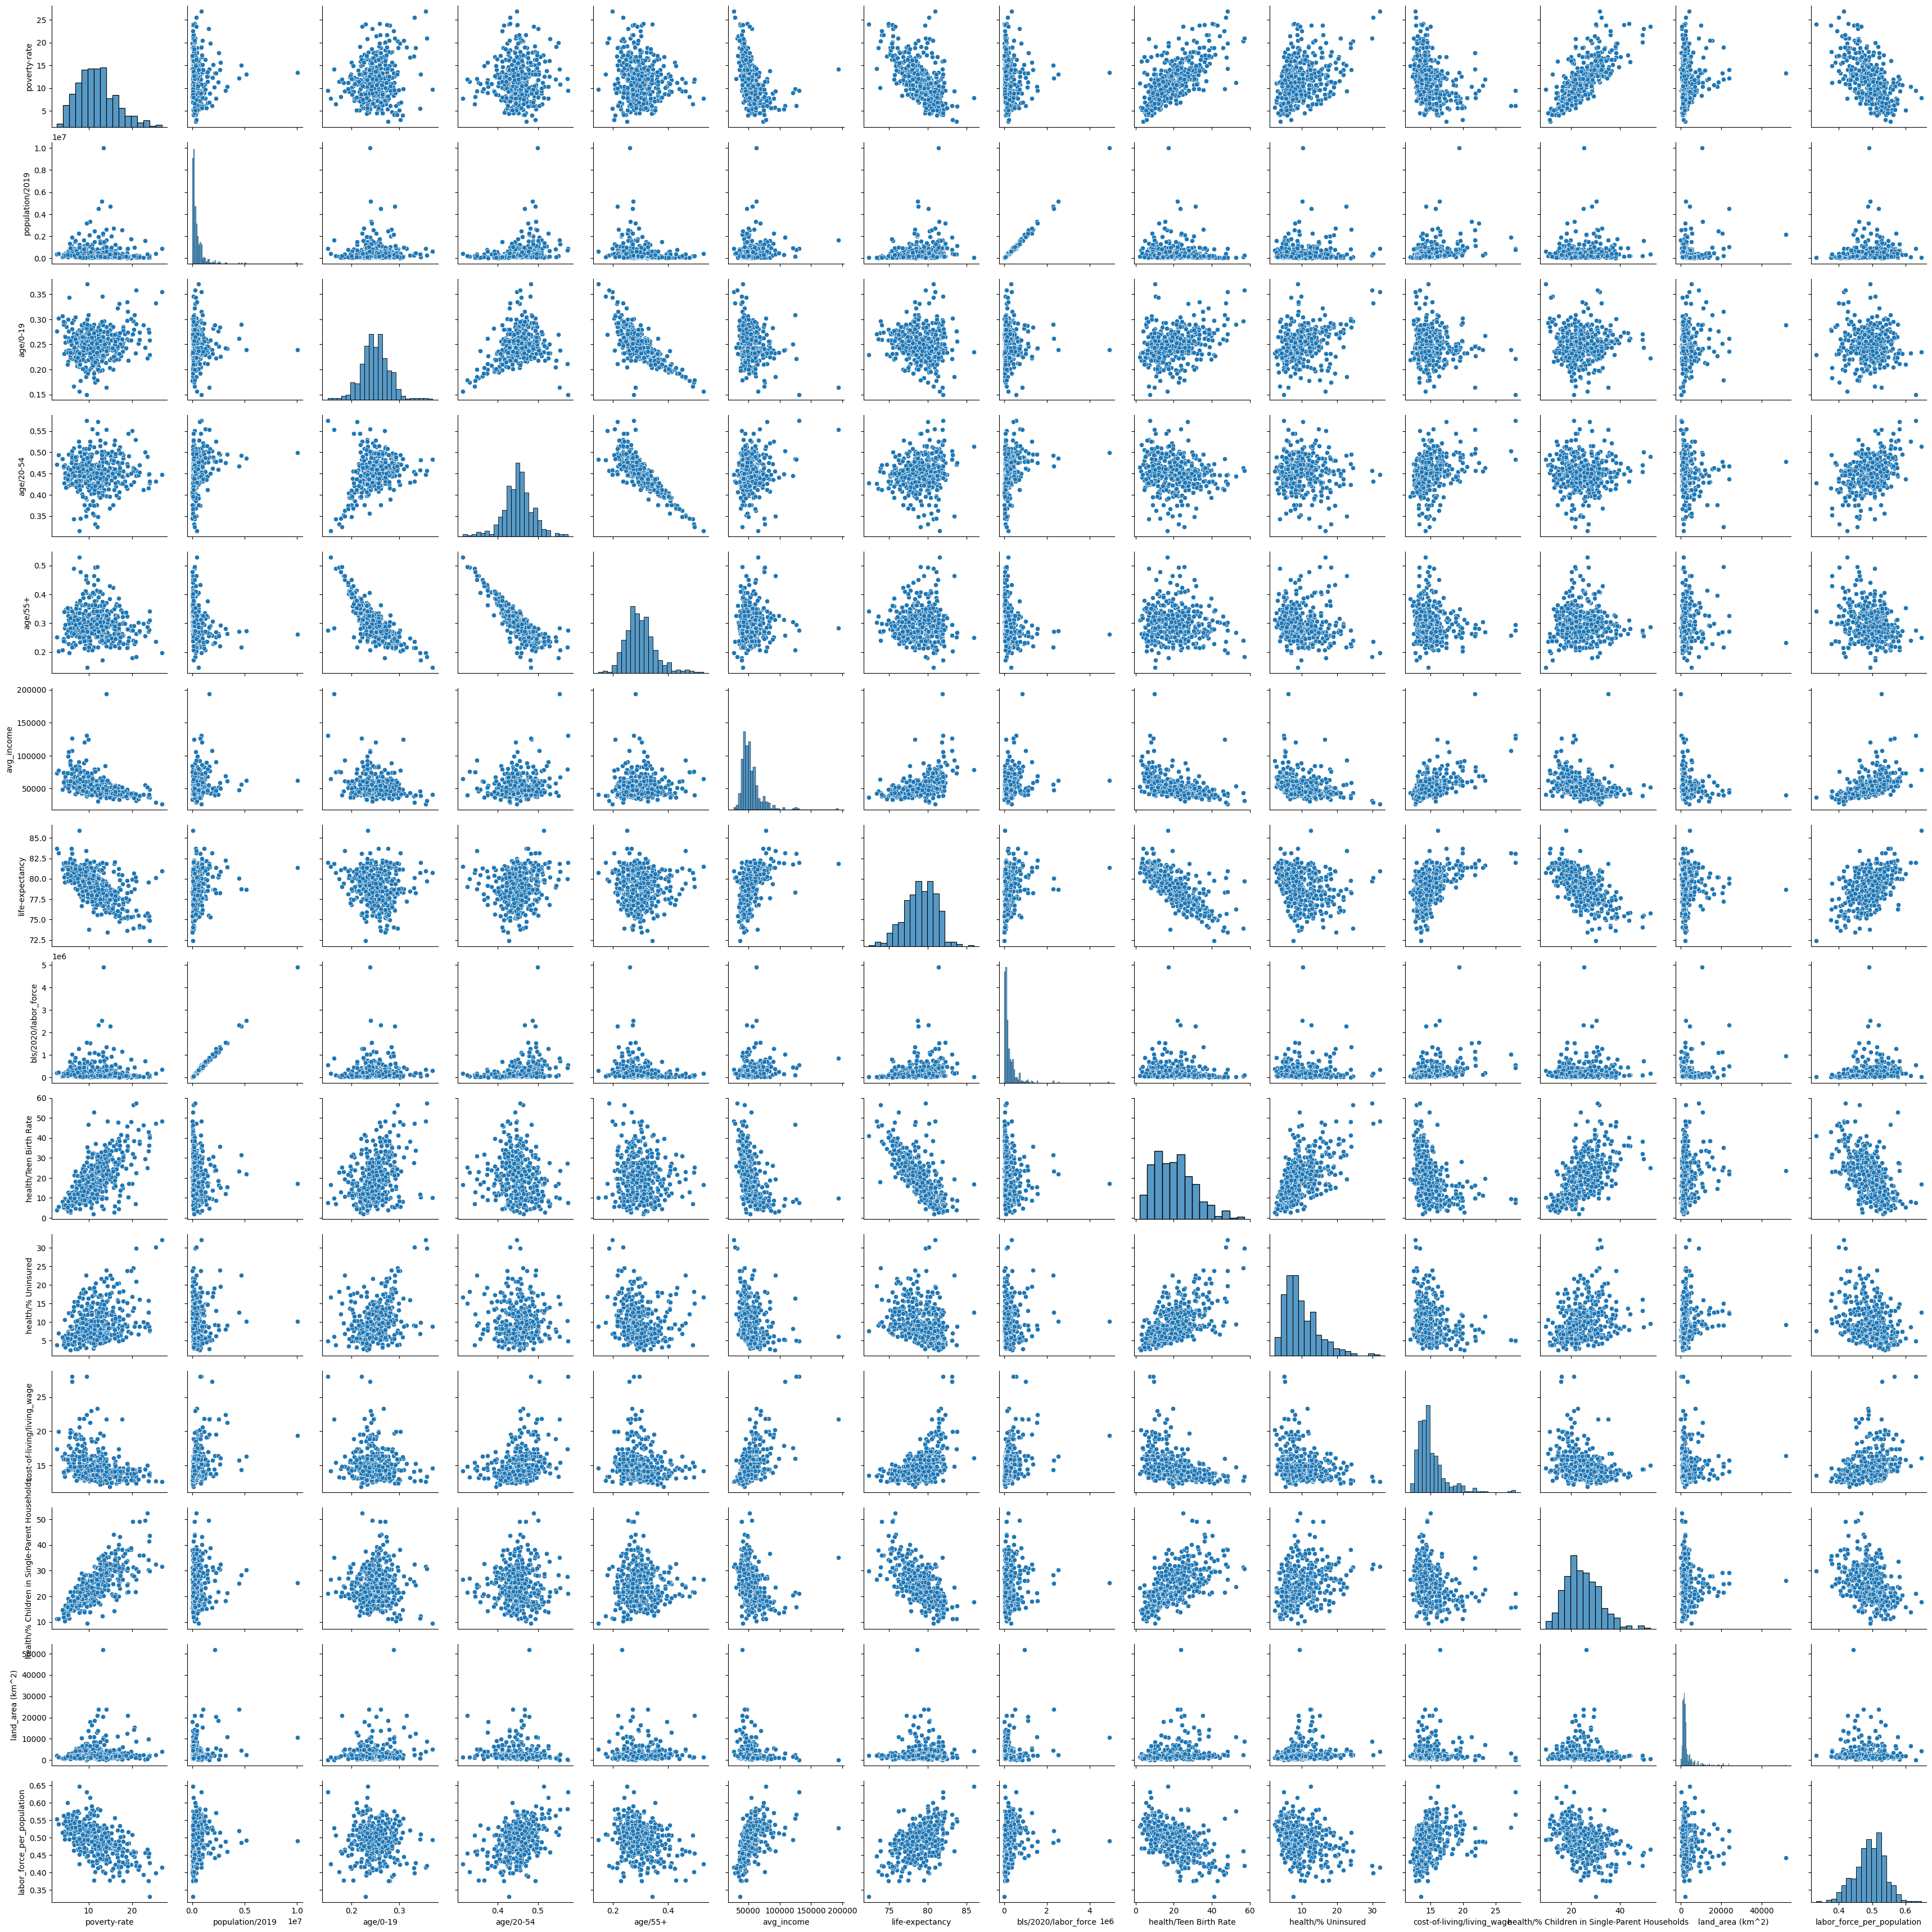

In [28]:
sns.pairplot(counties_reduced)

I made a variable Labro Force Participation rate to more percisely measure labor force. More populous counties are adjusted for when you divide labor force by total pop.

In [29]:
counties_reduced['labor_force_per_population'] = counties_reduced['bls/2020/labor_force'] / counties_reduced['population/2019']
display(counties_reduced[['name', 'state', 'labor_force_per_population']].head())

,name,state,labor_force_per_population
30,douglas county,NE,0.525338
94,lewis county,WA,0.434944
98,snohomish county,WA,0.536632
99,yakima county,WA,0.521216
101,spokane county,WA,0.492175


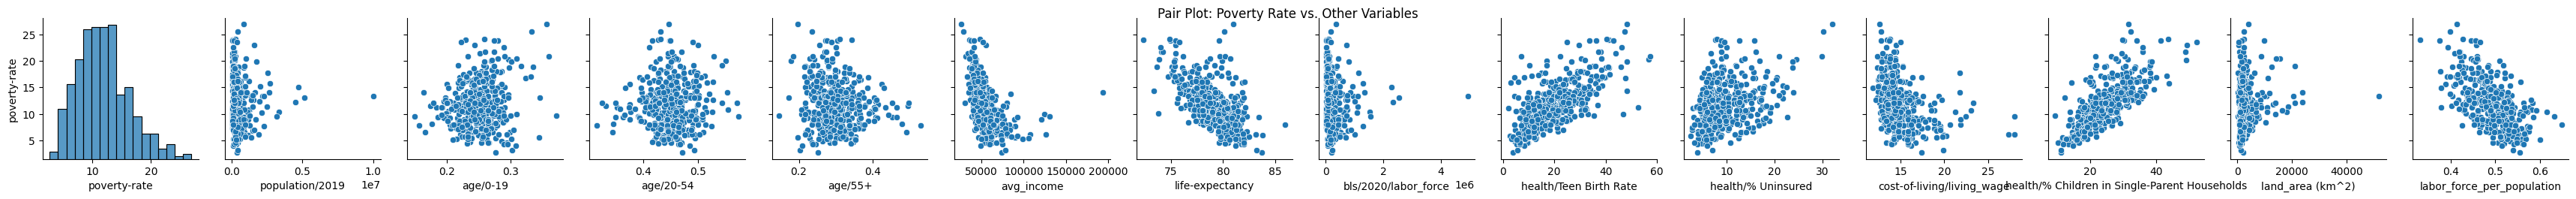

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(counties_reduced, y_vars=['poverty-rate'])
plt.suptitle('Pair Plot: Poverty Rate vs. Other Variables', y=1.02) # Adjust suptitle position
plt.show()

### First Culling of Variables

After looking at the pariplot, I decided to discount all variables with a labor force/population ratio over one, as I figure it is caused by out of country people communting for work. If people are commuting, I don't think they should be counted in the county they work in. Including the >1 ratios make it seem like the county in question is very employed when instead they are just employing people from different counties.

I also decided not to use the age variables because they had very little correleation.

In [31]:
print(f"Original number of rows: {len(counties_reduced)}")
counties_reduced = counties_reduced[counties_reduced['labor_force_per_population'] <= 1]
print(f"Number of rows after dropping: {len(counties_reduced)}")

Original number of rows: 410
Number of rows after dropping: 410


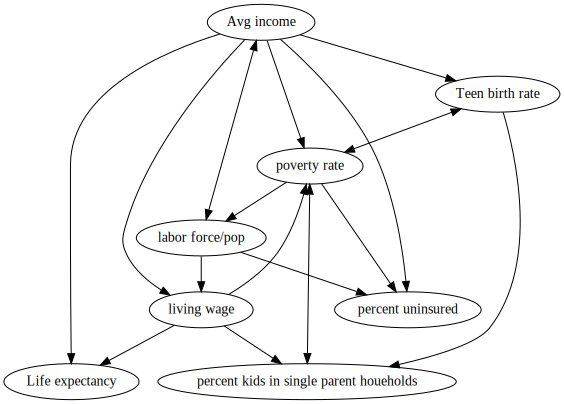

In [32]:
dag_b = gv.Digraph(comment='predicting poverty rate')
dag_b.node('I', 'Avg income')
dag_b.node('E','Life expectancy')
dag_b.node('S','percent kids in single parent houeholds')
dag_b.node('H','percent uninsured')
dag_b.node('T','Teen birth rate')
dag_b.node('L','labor force/pop')
dag_b.node('P','poverty rate')
dag_b.node('W','living wage')
dag_b.edges(['IE', 'WE', 'IH', 'IW', 'IP', 'IT', 'TS', 'PH', 'LH', 'LW', 'WS', 'PL', 'WP'])
dag_b.edge('I', 'L', dir='both')
dag_b.edge('T', 'P', dir='both')
dag_b.edge('P', 'S', dir='both')
dag_b

### Removing More Variables

I will not be using "percent uninsured" because it has a collider raltionship with poverty rate. Percent kids in single parent households is also potentially a collider, but I will use it in some models and potentially identify which direction the Poverty rate <--> kids in single parent households arrow goes.

I will not be including "life expectancy" as it is also a collider.

### Final Causal Diagram

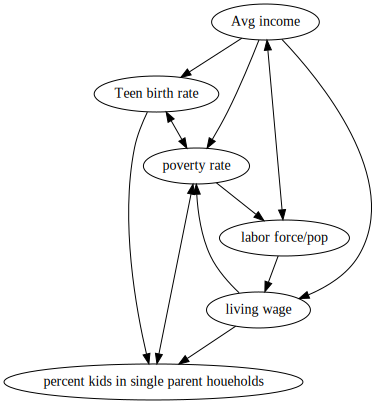

In [33]:
dag_b = gv.Digraph(comment='predicting poverty rate')
dag_b.node('I', 'Avg income')
##dag_b.node('E','Life expectancy')
dag_b.node('S','percent kids in single parent houeholds')
##dag_b.node('H','percent uninsured')
dag_b.node('T','Teen birth rate')
dag_b.node('L','labor force/pop')
dag_b.node('P','poverty rate')
dag_b.node('W','living wage')
dag_b.edges(['IW', 'IP', 'IT', 'TS', 'LW', 'WS', 'PL', 'WP'])
dag_b.edge('I', 'L', dir='both')
dag_b.edge('T', 'P', dir='both')
dag_b.edge('P', 'S', dir='both')
dag_b

### Likelihood analysis

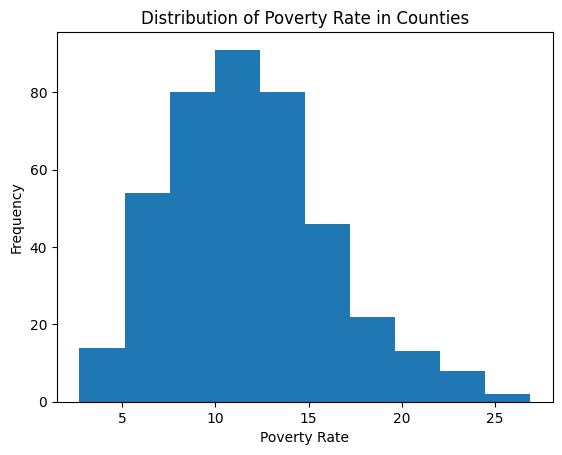

In [34]:
plt.hist(counties_reduced['poverty-rate'])
plt.title('Distribution of Poverty Rate in Counties')
plt.xlabel('Poverty Rate')
plt.ylabel('Frequency')
plt.show()

This looks gamma but I will be approximiating it as normal for my intial models.

### Inital Model: Bambi (no interactions)

In [ ]:
counties_reduced = counties_reduced.rename(columns={'poverty-rate': 'poverty_rate'})

reference_model_poverty = bmb.Model(
    "poverty_rate ~ `cost-of-living/living_wage` + labor_force_per_population + `health/Teen Birth Rate` + avg_income + `health/% Children in Single-Parent Households`",
    data=counties_reduced,
    family="gaussian", # Assuming a Gaussian family for the poverty rate as an approximation for initial models
    link="identity"
)

idata_reference_model_poverty = reference_model_poverty.fit(
    idata_kwargs={"log_likelihood": True},
    target_accept=0.9,
    draws=2000,
    chains=4,
    max_treedepth=10
)

/usr/local/lib/python3.12/dist-packages/bambi/models.py:922: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


<Axes: xlabel='poverty_rate'>

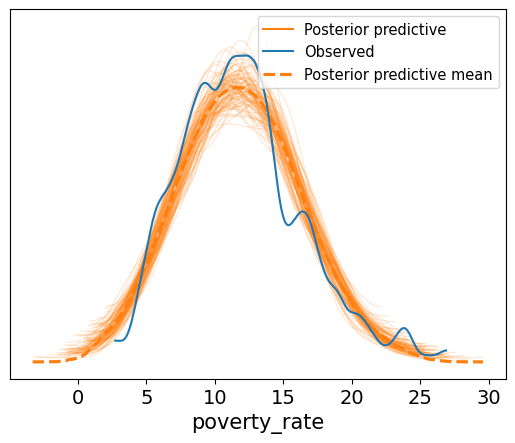

In [36]:
reference_model_poverty.predict(idata_reference_model_poverty, kind="pps")
az.plot_ppc(idata_reference_model_poverty, num_pp_samples=100, colors=["C1", "C0", "C1"])

This looks pretty good even without interactions. This is a good sanity check that a normal likelihood is fine.  

In [37]:
posterior_mean = idata_reference_model_poverty.posterior["mu"]

μ_hdi = az.hdi(ary=idata_reference_model_poverty, group="posterior", var_names=["mu"], hdi_prob=0.74)

pps = az.extract(
    idata_reference_model_poverty, group="posterior_predictive", var_names=["poverty_rate"]
).T
##gemini changed Mu from latin symbol

### Bambi model scatterplot

/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


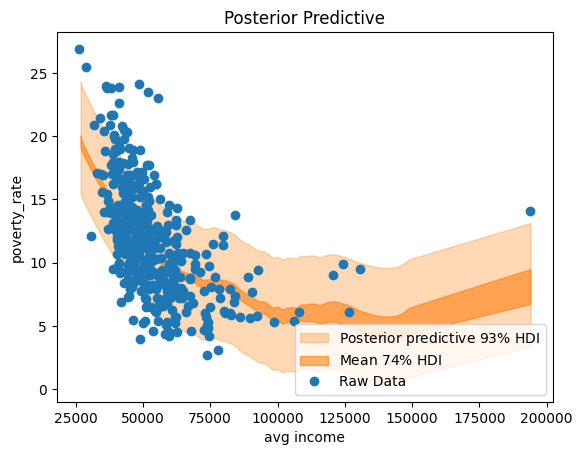

In [38]:
idx = np.argsort(counties_reduced['avg_income'])
fig, ax = plt.subplots()

az.plot_hdi(
    x=counties_reduced.to_numpy()[:, 7],#grab 7th column
    y=pps,
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": r"Posterior predictive $93\%$ HDI"},
)

az.plot_hdi(
    x=counties_reduced['avg_income'],
    y=posterior_mean,
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": r"Mean $74\%$ HDI"},
)
ax.plot(counties_reduced['avg_income'], counties_reduced["poverty_rate"], "o", c="C0", label="Raw Data")
ax.legend(loc="lower right")
ax.set(
    title="Posterior Predictive",
    xlabel="avg income",
    ylabel="poverty_rate",
);

This, again, seems good when sorting by average income, but there are some very high average income counties that have large weight in the model. It's not a problem in this vsaulization, though.

#### Bambi Model + Interactions

In [ ]:
# The rename line is removed to use the original column names
counties_reduced = counties_reduced.rename(columns={'poverty-rate': 'poverty_rate'})

model_poverty_int = bmb.Model(
    "poverty_rate ~ `cost-of-living/living_wage` + labor_force_per_population + `health/Teen Birth Rate` + `avg_income` + `health/% Children in Single-Parent Households` + `avg_income`:`labor_force_per_population` + `avg_income`:`health/Teen Birth Rate` + `labor_force_per_population`:`cost-of-living/living_wage` + `cost-of-living/living_wage`:`health/% Children in Single-Parent Households`",
    data=counties_reduced,
    family="gaussian", # Assuming a Gaussian family for the poverty rate as an approximation for initial models
    link="identity"
)

idata_model_poverty_int = model_poverty_int.fit( # Changed variable name and model
    idata_kwargs={"log_likelihood": True},
    target_accept=0.9,
    draws=2000,
    chains=4,
    max_treedepth=10
)

In [43]:
!pip install pymc-bart
import pymc_bart as pmb

In [44]:
import pymc_bart as pmb

### Initial Bart Model

In [ ]:
Y = counties_reduced['poverty_rate'].values
x_vars_model1 = [
    'cost-of-living/living_wage',
    'labor_force_per_population',
    'health/Teen Birth Rate',
    'avg_income',
    'health/% Children in Single-Parent Households'
]
X = counties_reduced[x_vars_model1].values

with pm.Model() as model_counties:
    s = pm.HalfNormal('s',20) #sigma = 20 is a blind guess
    μ_ = pmb.BART("μ_", X, np.log(Y), m=50) #log around Y
    μ = pm.Deterministic("μ",(μ_))
    y = pm.Gamma("y", mu=μ, sigma=s,  observed=Y) #likelihood
    idata_counties = pm.sample(compute_convergence_checks=False)

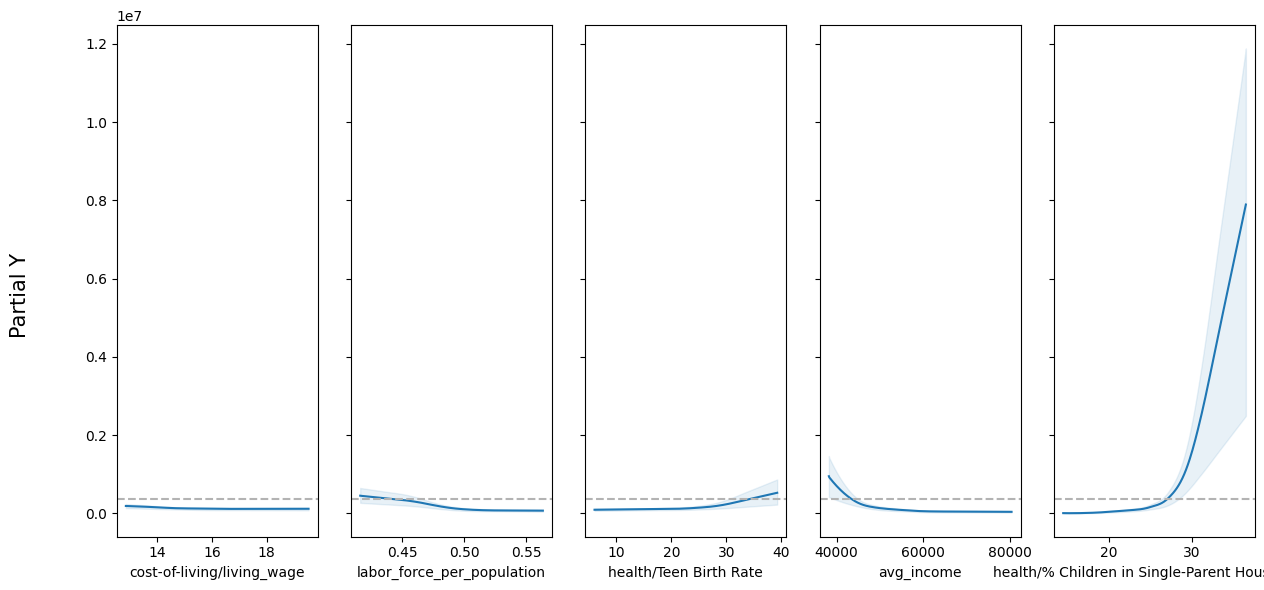

In [50]:
axes = pmb.plot_pdp(μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))
for i, ax in enumerate(axes):
    ax.set_xlabel(x_vars_model1[i])
plt.tight_layout()
plt.show()

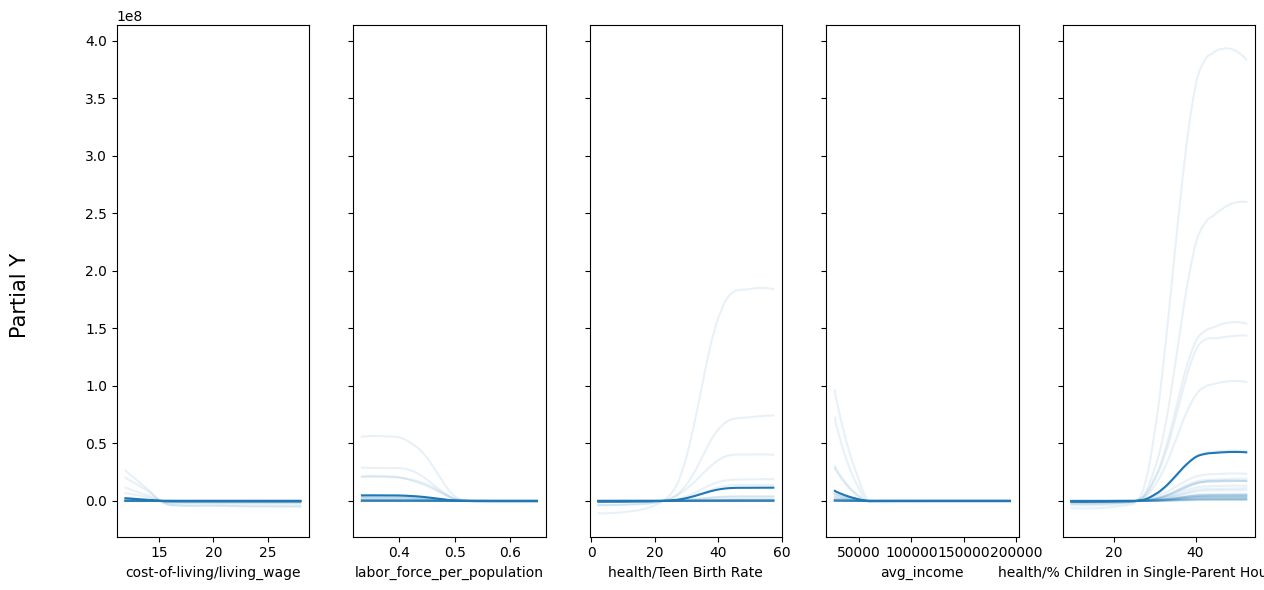

In [53]:
axes = pmb.plot_ice( μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))
for i, ax in enumerate(axes):
    ax.set_xlabel(x_vars_model1[i])
plt.tight_layout()
plt.show()

There could be interactions I am mising between each variable, but more likely the high leverage points are making the model confused.

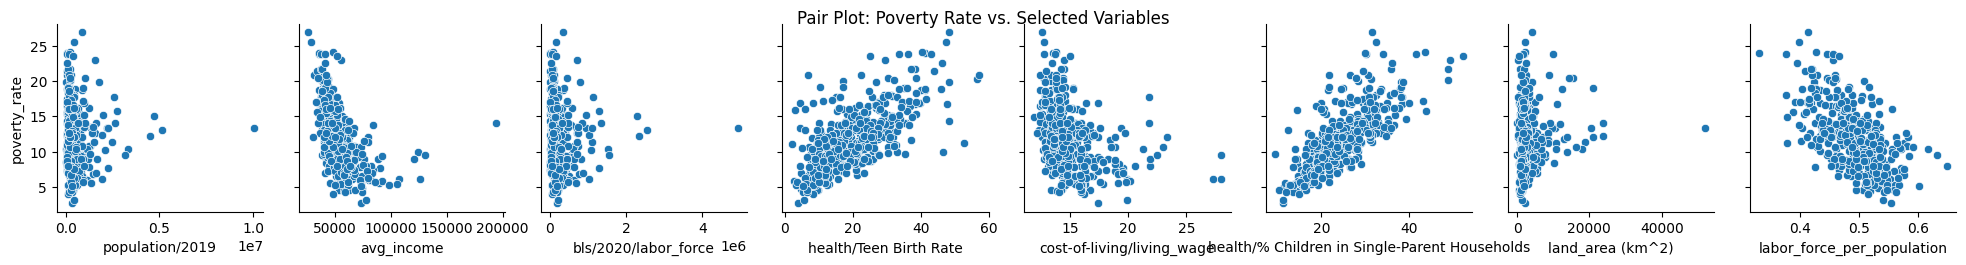

In [54]:
columns_to_exclude = [
    'age/0-19',
    'age/20-54',
    'age/55+',
    'health/% Uninsured',
    'life-expectancy',
    'name', # Exclude non-numeric/identifier columns if desired
    'state'  # Exclude non-numeric/identifier columns if desired
]

x_vars_for_pairplot = [col for col in counties_reduced.columns if col not in columns_to_exclude and col != 'poverty_rate']

sns.pairplot(counties_reduced, y_vars=['poverty_rate'], x_vars=x_vars_for_pairplot)
plt.suptitle('Pair Plot: Poverty Rate vs. Selected Variables', y=1.02) # Adjust suptitle position
plt.show()

In [ ]:
pm.sample_posterior_predictive(idata_counties,model_counties, extend_inferencedata=True)

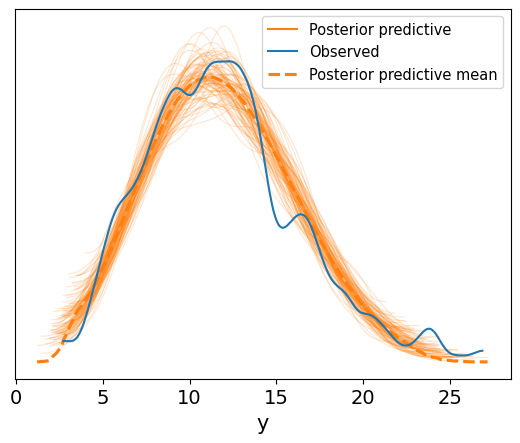

In [56]:
ax = az.plot_ppc(idata_counties, num_pp_samples=100, colors=["C1", "C0", "C1"])

In [57]:
vi_counties = pmb.compute_variable_importance(idata_counties, μ_, X)

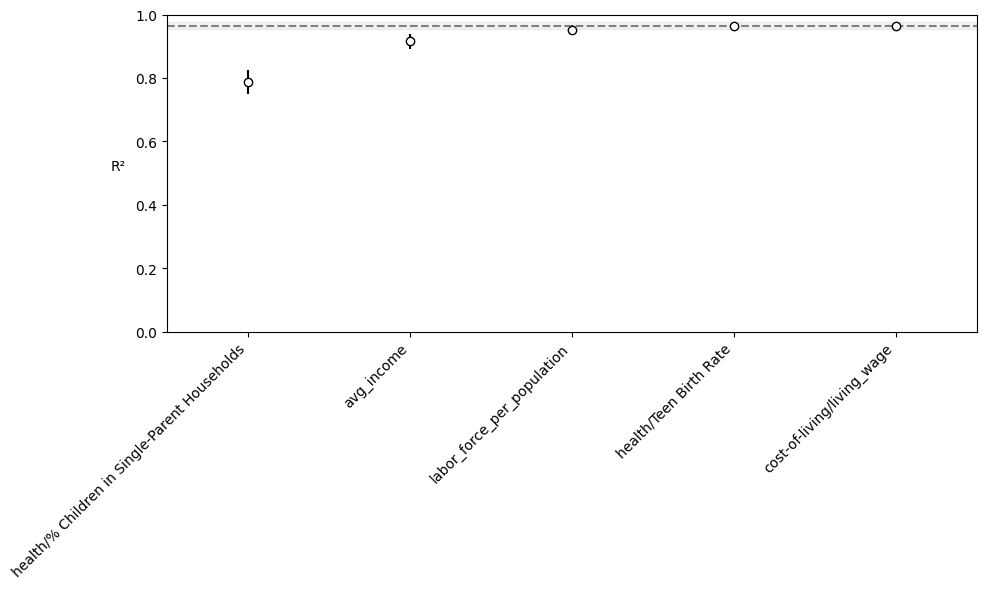

In [62]:
ax = pmb.plot_variable_importance(vi_counties, figsize=(10, 6))

# Get the variable names in the order of importance
ordered_x_vars = [x_vars_model1[i] for i in vi_counties['indices']]

# Set the x-tick labels and rotate them for better readability
ax.set_xticklabels(ordered_x_vars, rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
Y = counties_reduced['poverty_rate'].values
X = counties_reduced[[
    'cost-of-living/living_wage',
    'labor_force_per_population',
    'health/Teen Birth Rate',
    'avg_income',
    'health/% Children in Single-Parent Households'
]].values

with pm.Model() as model_counties2:
    s = pm.HalfNormal('s',50) #sigma = 50 is a blind guess
    μ_ = pmb.BART("μ_", X, np.log(Y), m=50) # Model log(Y) with BART
    μ = pm.Deterministic("μ", pm.math.exp(μ_)) # Exponentiate to get positive mean
    y = pm.Gamma("y", mu=μ, sigma=s,  observed=Y) #likelihood
    idata_counties2 = pm.sample(compute_convergence_checks=False)

In [ ]:
pm.sample_posterior_predictive(idata_counties2,model_counties2, extend_inferencedata=True)

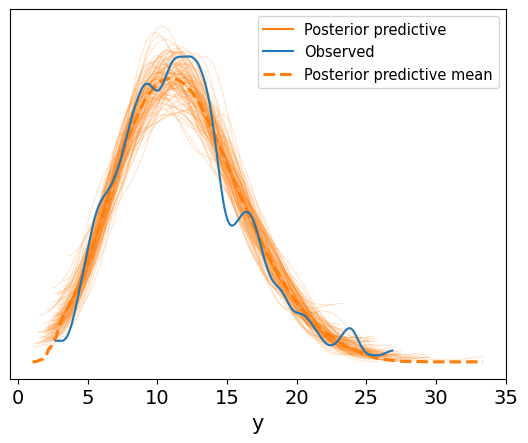

In [68]:
ax = az.plot_ppc(idata_counties2, num_pp_samples=100, colors=["C1", "C0", "C1"])

### Creating `counties_no_big` by excluding top 5 income/population counties

In [69]:
# Identify top 5 counties by avg_income
top_5_income_counties = counties_reduced.nlargest(5, 'avg_income')['name'].tolist()

# Identify top 5 counties by population/2019
top_5_population_counties = counties_reduced.nlargest(5, 'population/2019')['name'].tolist()

# Combine and get unique top counties to exclude
counties_to_exclude = list(set(top_5_income_counties + top_5_population_counties))

print(f"Counties with top 5 income or population to be excluded: {counties_to_exclude}")

# Create the new dataset by excluding these counties
counties_no_big = counties_reduced[~counties_reduced['name'].isin(counties_to_exclude)].copy()

display(counties_no_big.head())
print(f"Original number of rows: {len(counties_reduced)}")
print(f"Number of rows in counties_no_big: {len(counties_no_big)}")

Counties with top 5 income or population to be excluded: ['new york county', 'san francisco county', 'midland county', 'fairfield county', 'los angeles county', 'san mateo county', 'maricopa county', 'harris county', 'cook county', 'san diego county']


,name,state,poverty_rate,population/2019,age/0-19,age/20-54,age/55+,avg_income,life-expectancy,bls/2020/labor_force,health/Teen Birth Rate,health/% Uninsured,cost-of-living/living_wage,health/% Children in Single-Parent Households,land_area (km^2),labor_force_per_population
30,douglas county,NE,10.2,571327,0.281110,0.468460,0.250429,63435,78.64,300140.0,22.319430,10.444150,14.93,25.001223,850.764861,0.525338
94,lewis county,WA,12.2,80707,0.234044,0.405368,0.360588,43453,78.07,35103.0,29.988392,8.938158,12.85,20.249314,6223.151001,0.434944
98,snohomish county,WA,7.0,822083,0.244056,0.482527,0.273418,55888,80.15,441156.0,12.169574,7.162159,19.57,18.030925,5404.083801,0.536632
99,yakima county,WA,16.7,250873,0.322629,0.428978,0.248393,43379,78.44,130759.0,38.204812,15.853478,13.25,26.880736,11122.757370,0.521216
101,spokane county,WA,12.9,522798,0.245563,0.459562,0.294875,46466,78.90,257308.0,17.291302,6.529510,12.66,21.011541,4568.458718,0.492175


Original number of rows: 410
Number of rows in counties_no_big: 399


In [ ]:
Y = counties_no_big['poverty_rate'].values
x_vars_model2 = [
    'cost-of-living/living_wage',
    'labor_force_per_population',
    'health/Teen Birth Rate',
    'avg_income',
    'health/% Children in Single-Parent Households'
]
X = counties_no_big[x_vars_model2].values

with pm.Model() as model_counties_no_big:
    s = pm.HalfNormal('s',50) #sigma = 50 is a blind guess
    μ_ = pmb.BART("μ_", X, np.log(Y), m=50) # Model log(Y) with BART
    μ = pm.Deterministic("μ", pm.math.exp(μ_)) # Exponentiate to get positive mean
    y = pm.Gamma("y", mu=μ, sigma=s,  observed=Y) #likelihood
    idata_counties_no_big = pm.sample(compute_convergence_checks=False)

In [ ]:
pm.sample_posterior_predictive(idata_counties_no_big,model_counties_no_big, extend_inferencedata=True)

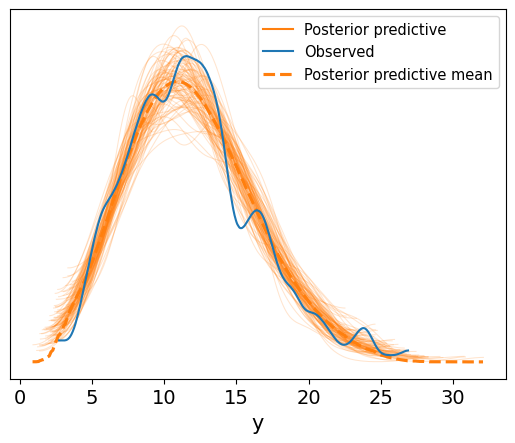

In [74]:
ax = az.plot_ppc(idata_counties_no_big, num_pp_samples=100, colors=["C1", "C0", "C1"])

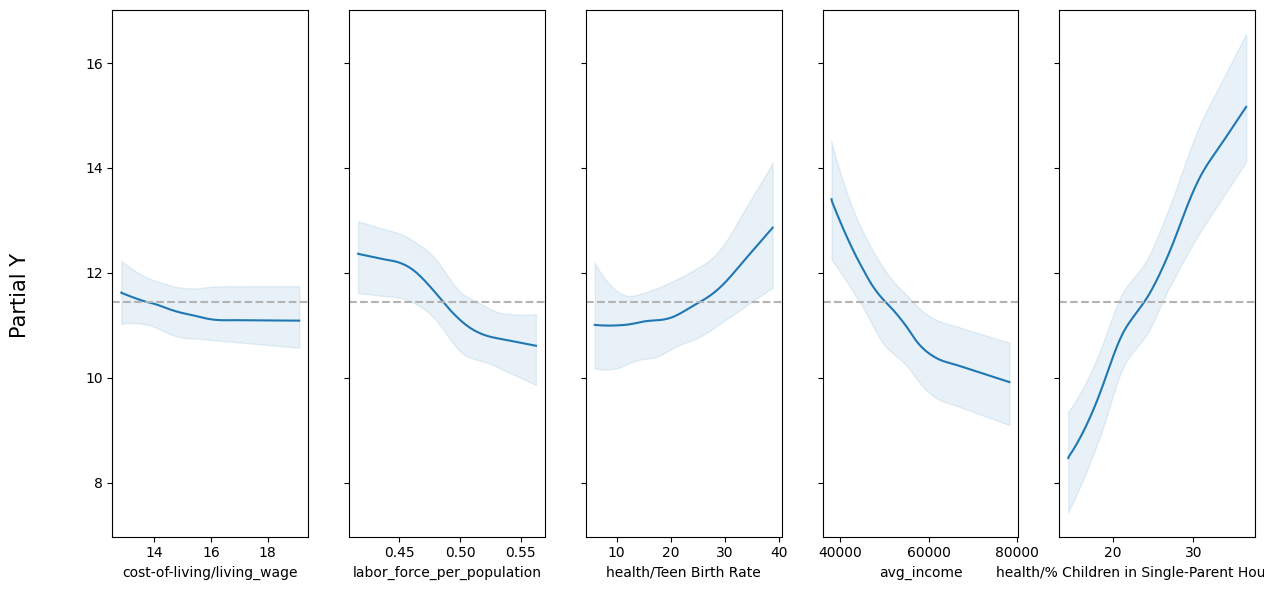

In [77]:
axes = pmb.plot_pdp(μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))
for i, ax in enumerate(axes):
    ax.set_xlabel(x_vars_model2[i])
plt.tight_layout()
plt.show()

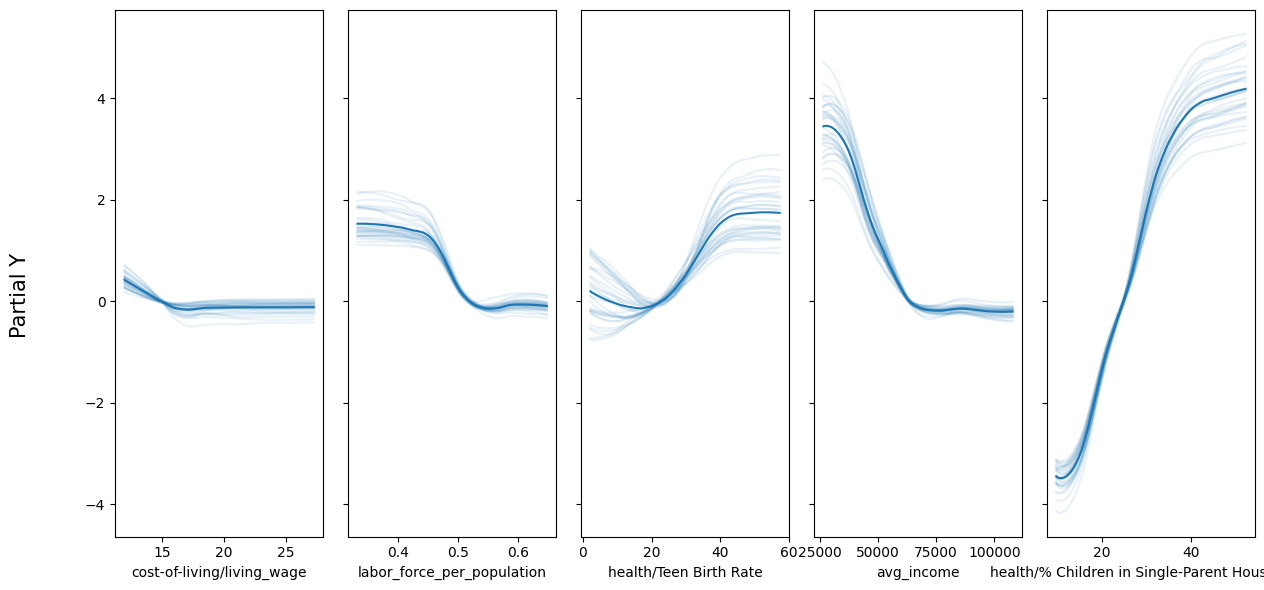

In [79]:
axes_no_big = pmb.plot_ice( μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))
for i, ax in enumerate(axes_no_big):
    ax.set_xlabel(x_vars_model2[i])
plt.tight_layout()
plt.show()

Removing the high leverage points made the model much more sure which trends to follow! I wasn't expecting living wage to have such a neglible effect, but I suspect it's affecting one of the other variables because of the cross in the ice plot.

Average income sensibly has a large effect on poverty rate. I was expecting it to have a very strong effect for low average incomes. I would like to have median income data to continue this investigation because of the skew on mean income.

I don't understand why very low labor force/pop values don't correleate with increased poverty rate. On the right half of the graph where it caps out that makes sense, because there's only so many people actually in the labor force. Possibly this is because of discouraged workers.

And finally it makes sense to me that increased numbers of children in single parent households would correleate to higher poverty because children are so expensive. I'm sure there are other reasons too, but that one is the most obvious to me.